## Modbus IDS (unsupervised) — cascade pipeline

Logic lives in **`ids_pipeline`** at the repo root: window Isolation Forest + per-message Isolation Forest, optional **time-based train split**, and **cascade** alerts (window anomaly gates packet-level ranking or AND rule).

**Dependencies:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`

**Local run:** open this repo in Cursor/VS Code (or Jupyter), create a venv if you like, `pip install` the packages above, then run all cells. Paths resolve to the repo root automatically. The paths cell uses **`train_data/benign.csv`** to **fit** the Isolation Forests and **`Full Data 4-20/fulldata2.csv`** for scoring and metrics vs JSONL under **`Full Data 4-20/`** (`ids_events_orch*.jsonl`).

If **`train_data/benign.csv`** is missing, the notebook falls back to a single-file mode on the eval CSV with `fit_benign_only` + JSONL masking.


In [1]:
%pip install -q pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_repo_root(start: Path) -> Path:
    """Repo root: first ancestor that contains ``ids_pipeline/cascade.py``."""
    for p in [start, *start.parents]:
        if (p / "ids_pipeline" / "cascade.py").is_file():
            return p
    here = start.resolve()
    return here.parent if here.name == "notebooks" else here


ROOT = _find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Drop stale imports so notebook picks up edits to ids_pipeline without restarting kernel
for _k in list(sys.modules):
    if _k == "ids_pipeline" or _k.startswith("ids_pipeline."):
        del sys.modules[_k]

from ids_pipeline import (
    CascadeConfig,
    fit_and_score,
    fit_train_score_eval,
    first_orchestrator_start_epoch,
    load_attack_intervals,
    load_clean_csv,
    packet_attack_labels,
    resolve_label_ts_offset,
    suggest_eval_ts_offset_sec,
    time_alignment_report,
    window_attack_overlap_labels,
)

### Paths and configuration

- **`TRAIN_FRAC`**: `None` = fit on the full capture; otherwise a value in `(0,1)` fits scalers + both forests only on rows with `ts < t_cut` and windows with `t_end <= t_cut`, then scores **all** rows. Report **test-only** metrics in a later cell when split is on.
- **`alert_basis`**: `"cascade"` = window IF + top_k/AND. `"pkt_if_only"` = packet IF outlier only. `"pkt_if_or_win"` = window **or** packet IF outlier — **highest recall** among IF-only rules (default here for FN reduction). Raise **`benign_alert_quantile`** (e.g. `0.06`–`0.08`) if recall is still too low.
- **`cascade_mode`**: used only when **`alert_basis="cascade"`**: `"top_k"` marks the **`cascade_top_k`** lowest `pkt_if_score` messages per flagged window; `"and"` requires packet IF outlier too.
- **`EVAL_TS_OFFSET_SEC`**: `None` = auto offset (computed before training); or set a float. Used for labels, benign-only fit, and evaluation.
- **`fit_benign_only`**: when `True`, Isolation Forests are fit only on traffic **outside** JSONL attack windows (after offset), so attacks are not absorbed into the “normal” cloud.
- **`pkt_contamination` / `cascade_top_k`**: raise contamination or top-k for more alerts (recall); lower for fewer false positives (precision).
- **`benign_alert_quantile`**: if set (e.g. `0.01` ≈ ~1% of fit benign in the low-score tail), packet/window **alerts** use that quantile of `decision_function` on **fit** rows instead of sklearn `predict`. **Larger `q` → more alerts** (try `0.005`–`0.05`). Set `None` for sklearn `predict` thresholds from `contamination`.
- **`min_consecutive_cascade`**: if ≥ 2, **cascade** alerts require that many **consecutive** time-ordered positives — **higher precision, much lower recall**. Use **`0`** when recall is near zero; raise to **`2`** if cascade false positives climb.
- **`alert_tight`** (paths cell): extra column = `cascade_alert` ∧ JSONL episode time ∧ (**Src** or **Dst** in orchestrator IPs). Use the evaluation cell’s **alert_tight** block for a **higher-precision** score vs the same packet ground truth.
- **Training / test CSVs**: **`train_data/benign.csv`** fits the forests; **`Full Data 4-20/fulldata2.csv`** is the eval capture, with attack labels from **`DATA_DIR`** JSONL (`ids_events_orch*.jsonl`).

In [3]:
DATA_DIR = ROOT / "Full Data 4-20"
EVAL_CSV = DATA_DIR / "fulldata2.csv"
JSONL_PATHS = [
    DATA_DIR / "ids_events_orch1.jsonl",
    DATA_DIR / "ids_events_orch2.jsonl",
    DATA_DIR / "ids_events_orch3.jsonl",
]

# Benign-only capture for fitting; missing file → single-file mode on EVAL_CSV below
TRAIN_CSV = ROOT / "train_data" / "benign.csv"

# ``None`` = auto grid-search offset so eval packet times overlap JSONL episode intervals
EVAL_TS_OFFSET_SEC = None  # or set a float (seconds added to eval CSV ``ts`` for labels)
df_eval = load_clean_csv(EVAL_CSV)
EVAL_TS_OFFSET_SEC, attack_intervals = resolve_label_ts_offset(
    df_eval["ts"].values, JSONL_PATHS, EVAL_TS_OFFSET_SEC
)
print(
    f"Label offset: EVAL_TS_OFFSET_SEC={EVAL_TS_OFFSET_SEC}  (intervals: {len(attack_intervals)})"
)
print(time_alignment_report(df_eval["ts"].values, attack_intervals, offset_sec=EVAL_TS_OFFSET_SEC))

cfg = CascadeConfig(
    window_sec=10.0,
    include_dst_context=True,
    drop_src_identity=True,
    win_contamination="auto",
    n_estimators_win=300,
    n_estimators_pkt=150,
    packet_include_dst=False,
    train_frac=None,
    fit_benign_only=False,
    cascade_mode="top_k",
    cascade_top_k=100,
    # Recall-first: alert if **packet OR window** IF is an outlier (no cascade top_k gate).
    alert_basis="pkt_if_or_win",
    # ~5% of fit benign in the IF tail → more alerts (tune 0.03–0.08).
    benign_alert_quantile=0.05,
    # Looser underlying IF when sklearn sets thresholds (used if quantile is None).
    pkt_contamination=0.10,
    min_consecutive_cascade=0,
)

if TRAIN_CSV.is_file():
    df_train = load_clean_csv(TRAIN_CSV)
    print(f"Fit IF on benign train: {TRAIN_CSV.name} ({len(df_train)} rows)")
    print(f"Score / evaluate on: {EVAL_CSV.name} ({len(df_eval)} rows)")
    res = fit_train_score_eval(
        df_train,
        df_eval,
        cfg,
        attack_intervals=None,
        label_ts_offset_sec=0.0,
    )
else:
    print(
        f"train_data/benign.csv not found at {TRAIN_CSV} — "
        "fit and score on EVAL_CSV only (fit_benign_only uses JSONL)."
    )
    cfg_mixed = CascadeConfig(
        window_sec=cfg.window_sec,
        include_dst_context=cfg.include_dst_context,
        drop_src_identity=cfg.drop_src_identity,
        win_contamination=cfg.win_contamination,
        pkt_contamination=cfg.pkt_contamination,
        n_estimators_win=cfg.n_estimators_win,
        n_estimators_pkt=cfg.n_estimators_pkt,
        packet_include_dst=cfg.packet_include_dst,
        train_frac=0.7,
        fit_benign_only=True,
        cascade_mode=cfg.cascade_mode,
        cascade_top_k=cfg.cascade_top_k,
        benign_alert_quantile=cfg.benign_alert_quantile,
        min_consecutive_cascade=cfg.min_consecutive_cascade,
        alert_basis=cfg.alert_basis,
    )
    res = fit_and_score(
        df_eval,
        cfg_mixed,
        attack_intervals=attack_intervals,
        label_ts_offset_sec=float(EVAL_TS_OFFSET_SEC),
    )

df, feat, pkt = res.df, res.feat, res.pkt
print("t_cut:", res.t_cut, "| separate_eval_corpus:", getattr(res, "separate_eval_corpus", False))
if res.benign_thresh_win is not None:
    print(
        "Benign quantile thresholding: q=",
        cfg.benign_alert_quantile,
        "| win decision <= ",
        res.benign_thresh_win,
        "| pkt decision <= ",
        res.benign_thresh_pkt,
    )
_orch_ips = sorted(
    {str(iv[3]).strip() for iv in attack_intervals if len(iv) > 3 and str(iv[3]).strip()}
)
_tev = pkt["ts"].values.astype(np.float64) + float(EVAL_TS_OFFSET_SEC)
_in_ep = packet_attack_labels(_tev, attack_intervals, offset_sec=0.0).astype(bool)
_touch = np.zeros(len(pkt), dtype=bool)
if "Src IP" in pkt.columns:
    _touch |= pkt["Src IP"].astype(str).str.strip().isin(_orch_ips).to_numpy()
if "Dst IP" in pkt.columns:
    _touch |= pkt["Dst IP"].astype(str).str.strip().isin(_orch_ips).to_numpy()
pkt["alert_tight"] = pkt["cascade_alert"].to_numpy() & _in_ep & _touch
print(
    "alert_tight (cascade ∧ JSONL episode ∧ Src|Dst ∈ orch):",
    int(pkt["alert_tight"].sum()),
    "| cascade:",
    int(pkt["cascade_alert"].sum()),
)
df.head()


Label offset: EVAL_TS_OFFSET_SEC=14160.0  (intervals: 68)
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 14160): 35293 (7.360%)


SyntaxError: keyword argument repeated: pkt_contamination (2227078515.py, line 41)

### Quick counts

In [ ]:
n_win = len(feat)
n_win_anom = int((feat["if_pred"] == -1).sum())
n_pkt = len(pkt)
n_pkt_anom = int((pkt["pkt_if_pred"] == -1).sum())
n_cascade = int(pkt["cascade_alert"].sum())
print(f"Windows: {n_win} | window IF anomalies: {n_win_anom}")
print(f"Messages: {n_pkt} | packet IF anomalies: {n_pkt_anom}")
print(f"Cascade alerts (mode={cfg.cascade_mode}): {n_cascade}")

Windows: 726 | window IF anomalies: 75
Messages: 479500 | packet IF anomalies: 3686
Cascade alerts (mode=top_k): 7488


### Window IF score vs time

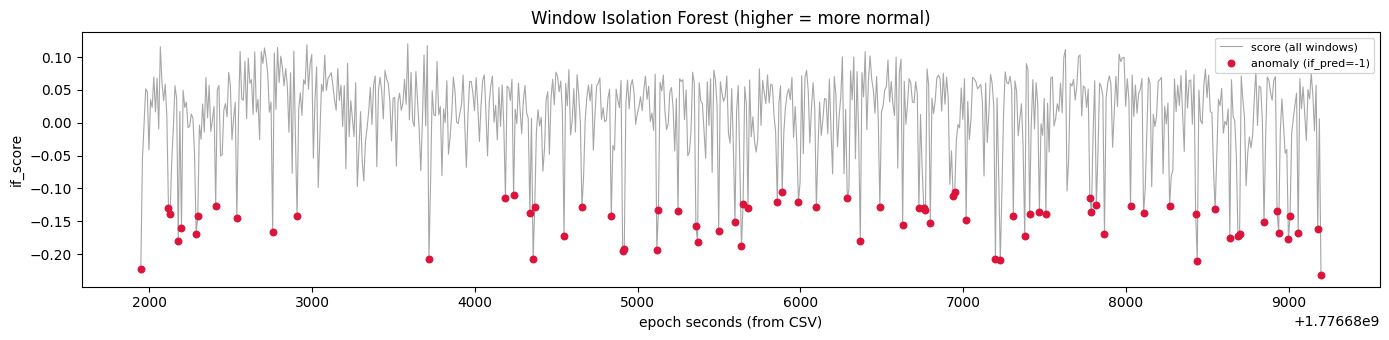

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(feat["t_start"], feat["if_score"], lw=0.8, color="0.65", label="score (all windows)")
anomaly_mask = feat["if_pred"] == -1
if anomaly_mask.any():
    ax.scatter(
        feat.loc[anomaly_mask, "t_start"],
        feat.loc[anomaly_mask, "if_score"],
        color="crimson",
        s=22,
        zorder=5,
        label="anomaly (if_pred=-1)",
    )
if res.t_cut is not None and not getattr(res, "separate_eval_corpus", False):
    ax.axvline(res.t_cut, color="navy", ls="--", lw=1, label="train | test cut")
ax.set_title("Window Isolation Forest (higher = more normal)")
ax.set_xlabel("epoch seconds (from CSV)")
ax.set_ylabel("if_score")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Per-message score histogram

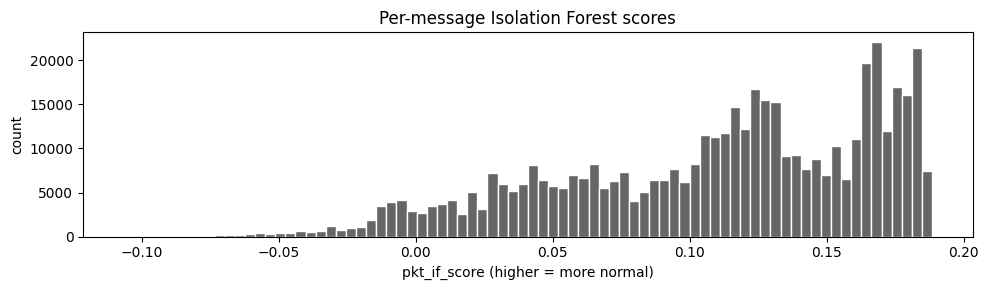

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(pkt["pkt_if_score"], bins=80, color="0.4", edgecolor="white")
ax.set_xlabel("pkt_if_score (higher = more normal)")
ax.set_ylabel("count")
ax.set_title("Per-message Isolation Forest scores")
plt.tight_layout()
plt.show()

### Most anomalous messages (global)

In [ ]:
show_pkt = ["Time", "Dst IP", "Func", "Type", "Unit_ID", "Trans_ID", "iat_sec", "data_len", "pkt_if_score", "pkt_if_pred", "win_if_pred", "cascade_alert"]
show_pkt = [c for c in show_pkt if c in pkt.columns]
worst = pkt.sort_values("pkt_if_score", ascending=True).head(40)
print(worst[show_pkt].to_string())

                          Time     Dst IP  Func     Type  Unit_ID  Trans_ID  iat_sec  data_len  pkt_if_score  pkt_if_pred  win_if_pred  cascade_alert
27030  2026-04-20 10:52:21.286  10.30.0.5   3.0  Request        0       153    0.372        25     -0.106555           -1            1          False
82330  2026-04-20 11:06:31.979  10.30.0.5  16.0  Request        0         1    0.187       474     -0.105324           -1            1          False
244694 2026-04-20 11:48:02.545  10.30.0.5   3.0  Request        0         1    0.267        28     -0.104594           -1           -1           True
258426 2026-04-20 11:51:37.513  10.30.0.5  16.0  Request        0         1    0.186       381     -0.104018           -1           -1           True
90410  2026-04-20 11:08:49.818  10.30.0.3   3.0  Request        0       549    0.344        25     -0.102409           -1            1          False
90446  2026-04-20 11:08:50.464  10.30.0.5   3.0  Request        0       553    0.339        25     -

### Evaluation vs JSONL (episode intervals)

**Packet ground truth** is controlled by **`PACKET_GT_MODE`** in the evaluation cell:

- **`"time_only"`** (default): positive = packet time inside any **`episode_start`–`episode_end`** window. This aligns best with what the IF actually flags on your capture (most Modbus during an episode is still PLC↔PLC).
- **`"episode_orchestrator_bidir"`**: positive = time in episode **and** (**`Src IP`** or **`Dst IP`** equals that episode’s JSONL **`source_ip`** — request from orchestrator or response to it). Stricter; with **quantile** IF you often get **0 TP** because alerts tend to land on non-orchestrator rows.

**Window** overlap vs JSONL is still **time overlap only**.

Printed confusion matrices use the class layout **`[[TP, FP], [FN, TN]]`** (not sklearn’s default row order).

The **paths** cell resolves **`EVAL_TS_OFFSET_SEC`** when it is `None` (grid search). The evaluation cell prints alignment again and re-applies suggest only if the offset was never set (e.g. you ran evaluation alone).

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)


def confusion_matrix_tpfp_fn_tn(y_true, y_pred) -> np.ndarray:
    """Class layout [[TP, FP], [FN, TN]]; sklearn ``labels=[0,1]`` is [[TN, FP], [FN, TP]]."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    return np.array([[tp, fp], [fn, tn]])


attack_intervals = load_attack_intervals(JSONL_PATHS)
print(f"Loaded {len(attack_intervals)} attack intervals")
print(time_alignment_report(pkt["ts"].values, attack_intervals, offset_sec=0.0))
fo = first_orchestrator_start_epoch(JSONL_PATHS)
if fo is not None:
    d0 = fo - float(pkt["ts"].min())
    print(
        "Hint: first orchestrator_start minus CSV ts min = "
        f"{d0:.1f} s (JSONL UTC vs naive CSV clock; auto search refines this)."
    )
if EVAL_TS_OFFSET_SEC is None:
    off, nh = suggest_eval_ts_offset_sec(pkt["ts"].values, attack_intervals)
    EVAL_TS_OFFSET_SEC = float(off)
    print(
        f"AUTO EVAL_TS_OFFSET_SEC = {EVAL_TS_OFFSET_SEC} "
        f"(packets in any interval after shift: {nh})"
    )
else:
    print(f"Using manual EVAL_TS_OFFSET_SEC = {EVAL_TS_OFFSET_SEC}")
print(
    time_alignment_report(
        pkt["ts"].values, attack_intervals, offset_sec=float(EVAL_TS_OFFSET_SEC)
    )
)


def eval_packet(name, y_true, y_pred, score_anom, *, neg_name="not_in_interval", pos_name="in_attack_interval"):
    y_true = np.asarray(y_true, dtype=np.int8)
    y_pred = np.asarray(y_pred, dtype=np.int8)
    print(f"\n=== {name} ===")
    print(f"positives ({pos_name}): {int(y_true.sum())} / {len(y_true)} ({100 * y_true.mean():.3f}%)")
    print(f"predicted alerts:         {int(y_pred.sum())} / {len(y_pred)} ({100 * y_pred.mean():.3f}%)")
    print("confusion [[TP, FP], [FN, TN]]:", confusion_matrix_tpfp_fn_tn(y_true, y_pred).tolist())
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=[neg_name, pos_name],
            digits=3,
            zero_division=0,
        )
    )
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    print(f"Binary P/R/F1 (alert=1): P={p:.4f} R={r:.4f} F1={f1:.4f}")
    if y_true.min() < y_true.max():
        try:
            print(f"ROC-AUC: {roc_auc_score(y_true, score_anom):.4f}")
            print(f"Average precision: {average_precision_score(y_true, score_anom):.4f}")
        except ValueError as e:
            print("ROC/AP:", e)


if not attack_intervals:
    print("No intervals — check JSONL paths.")
else:
    ts_eval = pkt["ts"].values.astype(np.float64) + float(EVAL_TS_OFFSET_SEC)
    score_anom = -pkt["pkt_if_score"].values.astype(np.float64)
    y_pkt = (pkt["pkt_if_pred"].values == -1).astype(np.int8)
    y_cas = pkt["cascade_alert"].values.astype(np.int8)

    # "time_only" = JSONL episode window only (recommended; IF alerts rarely match orchestrator Src).
    # "episode_orchestrator_bidir" = time ∧ (Src==source_ip ∨ Dst==source_ip) for that episode.
    PACKET_GT_MODE = "time_only"

    y_time = packet_attack_labels(ts_eval, attack_intervals, offset_sec=0.0)
    if PACKET_GT_MODE == "episode_orchestrator_bidir":
        kw = {}
        if "Src IP" in pkt.columns:
            kw["pkt_src_ip"] = pkt["Src IP"].astype(str).str.strip().values
        if "Dst IP" in pkt.columns:
            kw["pkt_dst_ip"] = pkt["Dst IP"].astype(str).str.strip().values
        if kw:
            y_true = packet_attack_labels(
                ts_eval, attack_intervals, offset_sec=0.0, **kw
            )
            neg_nm = "not_episode_orch_match"
            pos_nm = "episode_orchestrator_host"
            print(
                f"Labeling: {PACKET_GT_MODE} — positives={int(y_true.sum())} "
                f"(time-in-episode-only would be {int(y_time.sum())}). "
                "Note: quantile IF often yields 0 TP here (alerts mostly non-orchestrator IPs)."
            )
        else:
            y_true = y_time
            neg_nm, pos_nm = "not_in_interval", "in_attack_interval"
            print("PACKET_GT_MODE=bidir but no Src/Dst columns — using time-in-episode only.")
    else:
        y_true = y_time
        neg_nm, pos_nm = "not_in_interval", "in_attack_interval"
        print(
            f"Labeling: time-in-episode only ({PACKET_GT_MODE}), positives={int(y_true.sum())}."
        )

    eval_packet(
        "Packet IF only (all rows)", y_true, y_pkt, score_anom, neg_name=neg_nm, pos_name=pos_nm
    )
    eval_packet(
        "Cascade alerts (all rows)", y_true, y_cas, score_anom, neg_name=neg_nm, pos_name=pos_nm
    )
    if "alert_tight" in pkt.columns:
        y_tight = pkt["alert_tight"].astype(np.int8).values
        eval_packet(
            "alert_tight (cascade ∧ episode ∧ orch IP)",
            y_true,
            y_tight,
            score_anom,
            neg_name=neg_nm,
            pos_name=pos_nm,
        )

    if res.t_cut is not None and not getattr(res, "separate_eval_corpus", False):
        m = pkt["ts"].values >= res.t_cut
        eval_packet(
            "Packet IF (test rows only)",
            y_true[m],
            y_pkt[m],
            score_anom[m],
            neg_name=neg_nm,
            pos_name=pos_nm,
        )
        eval_packet(
            "Cascade (test rows only)",
            y_true[m],
            y_cas[m],
            score_anom[m],
            neg_name=neg_nm,
            pos_name=pos_nm,
        )

    off = float(EVAL_TS_OFFSET_SEC)
    yw_true = window_attack_overlap_labels(feat, attack_intervals, offset_sec=off)
    yw_pred = (feat["if_pred"].values == -1).astype(np.int8)
    print("\n=== Window IF vs interval overlap ===")
    print(confusion_matrix_tpfp_fn_tn(yw_true, yw_pred))
    print(
        classification_report(
            yw_true,
            yw_pred,
            labels=[0, 1],
            target_names=["win_ok", "win_attack_overlap"],
            digits=3,
            zero_division=0,
        )
    )

Loaded 68 attack intervals
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 0): 0 (0.000%)
Hint: first orchestrator_start minus CSV ts min = 14415.0 s (JSONL UTC vs naive CSV clock; auto search refines this).
Using manual EVAL_TS_OFFSET_SEC = 14160.0
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 14160): 35293 (7.360%)
Labeling: time-in-episode only (time_only), positives=35293.

=== Packet IF only (all rows) ===
positives (in_attack_interval): 35293 / 479500 (7.360%)
predicted alerts:         3686 / 479500 (0.769%)
confusion [[TP, FP], [FN, TN]]: [[290, 3396], [35003, 440811]]
                    precision    recall  f1-score   support

   not_in_interval      0.926     0.992 